### Strategy Overview

The strategy we have utilised seeks to capitalise on trend reversals and momentum shifts by combining signals from 3 indicators: Moving Average Convergence Divergence (MACD), Relative Strength Index (RSI), and Exponential Moving Average (EMA). Broadly, it adapts the position size based on the strength of these indicators to optimise returns while managing risk.

Entry and Exit Rules

1. For Long Position,
    MACD Line > Signal Line (bullish crossover) and Price > EMA (Uptrend confirmation)
    Position Size :
                    RSI < 30 (Oversold conditions hence opting for larger allocation of capital (50% of capital) in long)
                    30 < RSI < 70 (Equal capital split amongst number of stocks)
    

2. For Short Position,
    MACD Line < Signal Line (bearish crossver) and Price < EMA (Downtrend confirmation)
    Position Size:
                    RSI > 70 (Overbought conditions hence opting for larger allocation of capital (50% of capital) in short)
                    30 < RSI < 70 (Equal capital split amongst number of stocks)


In [ ]:
# import all libraries
!pip install ta
from ta.utils import dropna
from ta.volatility import BollingerBands, AverageTrueRange
from ta.trend import ADXIndicator, SMAIndicator, MACD, EMAIndicator
from ta.momentum import RSIIndicator
from ta.volume import VolumeWeightedAveragePrice

import math
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt


  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=39fbab035579f73ce3013c149171a3f28250f3e8fa1079252c6cb174bd4d34f3
  Stored in directory: /root/.cache/pip/wheels/5f/67/4f/8a9f252836e053e532c6587a3230bc72a4deb16b03a829610b
Successfully built ta


In [ ]:
# Variables
initial_capital = 500000
training_start = "2010-01-01"
training_end = "2016-12-31"
testing_start = "2017-01-01"
testing_end = "2019-12-31"
transaction_cost = 0

In [ ]:
class Common_Class():

  def __init__(self, symbol, start, end, backtrack, interval, capital, transaction_cost, verbose = True):

    #new dicts
    self.all_data ={}
    self.position = {} # position also a dict
    self.quantity = {} # quantity also a dict. initialising with zero quantitties to all the shares

    self.symbol = symbol[:-1]
    self.benchmark = symbol[-1]
    for stock in self.symbol:
      self.quantity['{}'.format(stock)] = 0

    self.start = start
    self.end = end
    self.backtrack = backtrack # this is the number of days to backtrack to ensure that there is no lag between signal generation and start date.
    self.interval = interval
    self.initial_capital = capital # this is the initial capital you want to trade with
    self.capital = capital # this capital will change depending on trades
    self.transaction_cost = transaction_cost # the transaction cost for trading
    self.trades = 0 # Number of trades
    self.verbose = verbose # if you want to see detailed output (logs)
    self.stored_data = pd.DataFrame(columns = ['trade', 'date', 'position', 'price', 'symbol', 'quantity', 'capital']) # to store trade details
    self.prepare_data() # prepares the data


  def prepare_data(self):
    # since we are building a common class for all types of strategy, we will not calcualte the moving averages now.
    # we will calculate the returns though.
    # Since most strategies utilise close prices we are only factoring close price. However, you can alter acoordingly.

    for i in self.symbol:
      stock_data = yf.Ticker(i)
      # Generate a range of trading days in reverse, offsetting backwards
      trading_days = pd.bdate_range(end=self.start, periods=self.backtrack + 1)
      new_start_date = trading_days[0]

      # Now, we are storing data from backtrack size before 2010-01-01 to calculate indicator values later
      hist_stock = stock_data.history(start = new_start_date, end = self.end, interval = self.interval)
      bt_data = pd.DataFrame()
      bt_data["Close_Price"] = hist_stock["Close"]
      bt_data["Return"] = np.log(bt_data["Close_Price"] / bt_data["Close_Price"].shift(1))
      bt_data = bt_data.dropna()
      self.all_data['{}'.format(i)] = bt_data

    # Storing S&P500 index Close Price and Daily Log Returns
    stock_data = yf.Ticker(self.benchmark)
    hist_stock = stock_data.history(start = self.start, end = self.end, interval = self.interval)
    bt_data = pd.DataFrame()
    bt_data["Close_Price"] = hist_stock["Close"]
    bt_data["Return"] = np.log(bt_data["Close_Price"] / bt_data["Close_Price"].shift(1))
    bt_data = bt_data.dropna()
    self.all_data['^GSPC'] = bt_data

  def close_graph(self, stock):
    i = str(stock)
    plt.figure(figsize=(15, 5))
    plt.plot(self.all_data[i]["Close_Price"] ,color='black', label='Price', linestyle='dashed')
    plt.xlabel("Days")
    plt.ylabel("Price")
    plt.title("Close Prices of {}".format(i))
    plt.legend()
    plt.grid()
    plt.show()

  def return_date_price(self, bar, stock):
    # A bar is a unit of data at a given time, depends on the interval you choose, it provides you OHLCV and time info
    # Since we have modeled close prices, we will get the price and date
    i = str(stock)
    date = str(self.all_data[i].index[bar])[:10]
    price = self.all_data[i].Close_Price.iloc[bar]
    return date, price

  def realised_balance(self, bar):
    #Returns you the realised capital in your account at a given time period / bar
    date, price = self.return_date_price(bar, self.symbol[0]) # only concerned with date so any stock will do
    print("Date :{} | Realised Balance: {:0.1f}".format(date,self.capital))

  def unrealised_balance(self, bar):
    #Returns you the unrealised capital (trades in progress) in your account at a given time period / bar
    ub = 0
    for stock in self.symbol:
      date, price = self.return_date_price(bar, stock)
      ub =  ub + self.quantity['{}'.format(stock)] *price
    #print("Date :{} | Unrealised Balance: {:0.1f}".format(date,ub))

  def total_balance(self, bar):
    #Unrealised plus realised
    ub = 0
    for stock in self.symbol:
      date, price = self.return_date_price(bar, stock)
      ub =  ub + self.quantity['{}'.format(stock)] *price
    tb = ub + self.capital
    #print("Date :{} | Total Balance: {:0.1f}".format(date,tb))
    return tb

  def store_results(self, trade, date, position, price, symbol, quantity, capital):
    trade_detail = pd.DataFrame({'trade':pd.Series(trade), 'date':pd.Series(date), 'position':pd.Series(position), 'price':pd.Series(price), 'symbol':pd.Series(symbol), 'quantity':pd.Series(quantity), 'capital':pd.Series(capital) })
    self.stored_data = pd.concat([self.stored_data, trade_detail])

  def performance_plots(self):

    Final_result_data = self.Final_result_data #saving time to write self everywhere
    interval = str(self.interval)

    f,ax = plt.subplots(2,3,figsize=(20,10))

    #plot 1: Close Price of stock
    plt.subplot(2, 3, 1)
    for stock in self.symbol:
      plt.plot(self.all_data['{}'.format(stock)].loc[self.start:self.end]['Return'].cumsum(), label='{}'.format(stock), linestyle='dashed')
    plt.title("Cum Log returns of included stocks")
    plt.xlabel(interval)
    plt.legend()
    plt.grid()

    #plot 2: Histogram of strategy returns
    plt.subplot(2, 3, 2)
    plt.hist(Final_result_data['capital_log_returns'], bins = 35, label='Strategy Returns', linestyle='dashed')
    plt.title("Histogram of Strategy returns")
    plt.xlabel(interval)
    plt.legend()
    plt.grid()

    #plot 3: Strategy vs Instrument
    plt.subplot(2, 3, 3)
    plt.plot(Final_result_data['benchmark_returns_log_cum_sum'],color='red', label='Benchmark Returns', linestyle='dashed')
    plt.plot(Final_result_data['capital_returns_log_cum_sum'].dropna(), color='blue', label ='Strategy Returns')
    plt.title("Strategy Vs Benchmark Return Curve")
    plt.xlabel(interval)
    plt.legend()
    plt.grid()

    #plot 4: Drawdown
    plt.subplot(2, 3, 4)
    plt.plot(Final_result_data["capital_returns_log_cum_sum"].dropna(), label='Cum log returns')
    plt.plot(Final_result_data["Cum_Max"].dropna(), label =  'Max Drawdown')
    plt.title("Drawdown")
    plt.xlabel(interval)
    plt.legend()
    plt.grid()

    #plot 5: Equity Curve
    plt.subplot(2, 3,  5)
    plt.plot(Final_result_data["capital"].dropna(), label =  'Equity $')
    plt.title("Equity Curve")
    plt.xlabel(interval)
    plt.legend()
    plt.grid()

    plt.suptitle("Performance Plots")
    f.delaxes(ax[1,2]) # to delete the last subplot

    plt.show()

  def performance(self):

    # stored data has  [trade, date, position, price, symbol, quantity, capital]
    #Since the stocks are stored not in arranged manner, we need to arrange them so that we can get the entry price and exit price for each day
    #stored data has many rows, we will aggregate day wise

    df = pd.DataFrame() # creating a new dataframe to store aggregated values

    df['capital'] = self.stored_data.groupby('date').agg({'capital': 'mean'})
    # aggregating by mean because the run is done in loop (for all stocks in a list of symbols),
    # so each stock "date" will have the same capital accounting for all stocks

    trade_start_date = df['capital'].index[0] # If intraday, then index needs to be adjusted with time.
    trade_end_date = df['capital'].index[-1] # This will work when interval is 1D

    #track benchmark S&P500 index as well, starting from the date where first trade happened, for fair comparison
    benchmark_returns = (self.all_data['^GSPC'][trade_start_date:trade_end_date]['Return'].tolist()) # The returns are already log
    df['benchmark_log_returns'] = benchmark_returns
    df['benchmark_returns_log_cum_sum'] = df['benchmark_log_returns'].cumsum()

    df['capital_after_settlement'] = df['capital'].shift(-1)
    # Since we are are utilising capital, we will calculate returns for SR based on daily capital/equity changes
    #Remember, you can change the returns on investment based on the capital you trade

    df['capital_regular_returns'] = (df['capital_after_settlement']/df['capital'] - 1)
    df['capital_log_returns'] = np.log(df['capital_after_settlement']/df['capital'])
    df["capital_returns_log_cum_sum"] = df["capital_log_returns"].cumsum()

    # for drawdown calculation
    df["Cum_Max"] = df["capital_returns_log_cum_sum"].cummax()
    df["drawdown"] = df["Cum_Max"] - df["capital_returns_log_cum_sum"]
    # The maximum difference is referred to as "Drawdown"

    df.drop(df.index[df['capital_log_returns'] == 0.0], inplace=True) #Dropping the last column, as I already got the values through shift(1)
    df = df.dropna()
    #print(df.head())

    #storing the results in Final_result data
    Final_result_data = df

    print("=" *50)
    print("Performance Metrics")

    #Total Balance
    print("The total capital at end of strategy: {:0.1f}".format(self.capital))

    # Annual gross expected returns
    daily_log_mean_ret = Final_result_data['capital_log_returns'].mean()
    annual_log_ret = 252 * daily_log_mean_ret
    annual_regular_return = (np.exp(annual_log_ret) -1)*100
    print("The annual regular returns: {:0.2f} %".format(annual_regular_return))

    # Benchmark annual expected returns
    benchmark_daily_log_mean_ret = Final_result_data['benchmark_log_returns'].mean()
    benchmark_annual_log_ret = 252 * benchmark_daily_log_mean_ret
    benchmark_annual_regular_return = (np.exp(benchmark_annual_log_ret) -1)*100
    print("The annual benchmark regular returns: {:0.2f} %".format(benchmark_annual_regular_return))

    # Annual std deviation
    daily_regular_std = (np.exp(Final_result_data['capital_log_returns'])-1).std()
    annual_regular_std =  daily_regular_std * (252 **0.5) *100
    print("The annual regular std deviation: {:0.2f} %".format(annual_regular_std))

    #Annual Sharpe Ratio
    SR = annual_regular_return / annual_regular_std
    print("The annual Sharpe Ratio: {:0.2f}".format(SR))

    #The strategy returns on investment in percent
    returns = (self.capital - self.initial_capital) /self.initial_capital *100
    print("The returns on investment from {} to {} by this strategy is {:0.1f} %".format(self.start, self.end, returns))

    #Calculate Drawdown
    Drawdown = Final_result_data["drawdown"].max()*100

    #Annual Sortino Ratio
    only_neg_log_returns = Final_result_data[Final_result_data['capital_log_returns']<0]['capital_log_returns']
    only_neg_regular_returns = np.exp(only_neg_log_returns)-1

    daily_std_dev_for_sortino = only_neg_regular_returns.std()
    annual_std_dev_for_sortino = daily_std_dev_for_sortino * (252 ** 0.5)*100

    sortino = annual_regular_return / annual_std_dev_for_sortino
    print("The annual Sortino Ratio: {:0.2f}".format(sortino))

    #Total trades
    print("The total trades taken by the strategy: {}".format(self.trades))


    print("=" *50)

    self.Final_result_data = Final_result_data
    #print(self.Final_result_data)
    return [annual_regular_return, annual_regular_std, SR, Drawdown, sortino]


  def buy_order(self,bar,stock,quantity=None, dollar =None ):
    date, price = self.return_date_price(bar,stock)
    if quantity == None:
      effective_dollar = dollar / (1+self.transaction_cost) # takes transaction cost into account
      quantity = int(effective_dollar/price)
    self.capital = self.capital - ((quantity * price)*(1 + self.transaction_cost)) # capital will be lost in buying
    self.quantity['{}'.format(stock)] = self.quantity['{}'.format(stock)] + quantity
    self.trades = self.trades + 1
    self.position['{}'.format(stock)] = 1
    tb = self.total_balance(bar)
    self.store_results(self.trades, date, self.position['{}'.format(stock)], price, stock, quantity, tb)

    if self.verbose:
      print("Bought {} shares of {} at {:0.2f} per share worth ${:0.2f}".format(quantity,stock, price, quantity * price))
      print('Total quantity for {} is {}'.format(stock,self.quantity['{}'.format(stock)]))
      self.realised_balance(bar)

  def sell_order(self,bar,stock, quantity=None, dollar=None ):
    date, price = self.return_date_price(bar, stock)
    if quantity == None:
      effective_dollar = dollar / (1+self.transaction_cost) # takes transaction cost into account
      quantity = int(effective_dollar/price)
    self.capital = self.capital + ((quantity * price)*(1 - self.transaction_cost)) # capital will be added after selling
    self.quantity['{}'.format(stock)] = self.quantity['{}'.format(stock)] - quantity
    self.trades = self.trades + 1
    self.position['{}'.format(stock)] = -1
    tb = self.total_balance(bar) # to store the total balance due to all the stocks at the end of the day, so that I get 1 value at the EOD
    self.store_results(self.trades, date, self.position['{}'.format(stock)], price, stock, quantity, tb)

    if self.verbose:
      print("Sold {} shares of {} at {:0.2f} per share worth ${:0.2f}".format(quantity,stock, price, quantity * price))
      print('Total quantity for {} is {}'.format(stock,self.quantity['{}'.format(stock)]))
      self.realised_balance(bar)


  def last_trade(self, bar): # this needs to be check for all open positions of all stocks

    for stock in self.symbol:
      date, price = self.return_date_price(bar, stock)
      last_quantity = self.quantity['{}'.format(stock)]
      self.capital = self.capital + last_quantity * price
      self.quantity['{}'.format(stock)] = 0 # as no more quantity now. all will be settled
      self.trades = self.trades +1
      if self.position['{}'.format(stock)] == -1: # if closing out a short position
        last_quantity = - last_quantity # to keep a positive number in records. Note, self.quantity is always maintaining a +/- sign.
        self.position['{}'.format(stock)] = 1 # to record we are buying to close out
      else:
        last_quantity =  last_quantity # to keep a positive number in records
        self.position['{}'.format(stock)] = -1 # to record we are selling to close out
      #self.position = 0
      tb = self.total_balance(bar)
      self.store_results(self.trades, date, self.position['{}'.format(stock)], price, stock, last_quantity, tb)

      if self.verbose:
        print("Closed open trades for {} shares of {} at {:0.2f} per share worth ${:0.2f}".format(last_quantity,stock, price, last_quantity * price))



In [ ]:
class RSI_MACD_EMA_Strategy(Common_Class):

  def go_long(self, bar, stock, dollar = None): # either previously in position or fresh position

    if self.position['{}'.format(stock)] == -1:
      self.position['{}'.format(stock)] = 0
      self.buy_order(bar,stock, quantity = -self.quantity['{}'.format(stock)]) #to clear previous short position and therefore negative quantity.(already in position, thats why negative)

    if dollar:
      self.buy_order(bar, stock, dollar=dollar) # buy dollar worth of the stock


  def go_short(self, bar, stock, dollar=None): # either previously in position or fresh position

    if self.position['{}'.format(stock)] == 1:
      self.position['{}'.format(stock)] = 0
      self.sell_order(bar,stock, quantity = self.quantity['{}'.format(stock)]) #to clear previous long position

    if dollar:
      self.sell_order(bar, stock, dollar = dollar)

  def run_strategy(self, macd_fast, macd_slow, macd_signal, ema_window, rsi_window=14): # add the parameters according to the strategy
    self.stop = False
    self.trades = 0
    self.capital = self.initial_capital

    #Preparing data with LTMA and STMA so that can check crossovers. Also initialising with 0 quantity and 0 position
    for stock in self.symbol:
      self.quantity['{}'.format(stock)] = 0
      self.position['{}'.format(stock)] = 0

      # RSI
      r = RSIIndicator(self.all_data['{}'.format(stock)]["Close_Price"], rsi_window)
      rsi = r.rsi()
      self.all_data['{}'.format(stock)]['RSI_{}'.format(stock)] = rsi

      # MACD
      m = MACD(self.all_data['{}'.format(stock)]["Close_Price"], window_fast=macd_fast, window_slow=macd_slow, window_sign=macd_signal)
      macd_values = m.macd()
      signal_values = m.macd_signal()
      self.all_data['{}'.format(stock)]['MACD_{}'.format(stock)] = macd_values
      self.all_data['{}'.format(stock)]['Signal_{}'.format(stock)] = signal_values

      # EMA
      e = EMAIndicator(self.all_data[f'{stock}']["Close_Price"], window=ema_window)
      ema = e.ema_indicator()
      self.all_data['{}'.format(stock)]['EMA_{}'.format(stock)] = ema


    for bar in range(ema_window, len(self.all_data['{}'.format(self.symbol[0])])): # from the available data bar to the last data bar
      #Making a func so that no trade if balance goes below 0

      tb = self.total_balance(bar)
      if tb< 0:
        print("negative capital")
        self.last_trade(bar)
        self.stop = True
        break

      # We keep track of the number of stocks we have in our portfolio for every bar
      # Starting with capital/5, as every stock is being traded, the remaining capital is split equally amongst the remaining stock left to be traded, if they are occurring.
      stock_number = len(self.symbol)

      for stock in self.symbol:
        date, price = self.return_date_price(bar, stock)

        # Accessing indicator values
        macd = self.all_data['{}'.format(stock)]['MACD_{}'.format(stock)].iloc[bar]
        signal = self.all_data['{}'.format(stock)]['Signal_{}'.format(stock)].iloc[bar]
        rsi = self.all_data['{}'.format(stock)]['RSI_{}'.format(stock)].iloc[bar]
        ema = self.all_data['{}'.format(stock)]['EMA_{}'.format(stock)].iloc[bar]
        rsi_oversold = 30
        rsi_overbought = 70

        if self.position['{}'.format(stock)] in [0,-1]: # checking no position or short position
          # We go long when the MACD signal is showing bullish crossover and EMA is showing uptrend confirmation
          if macd > signal and price > ema:
            # We trade more of our capital if RSI is favourable below 30
            if rsi < rsi_oversold:
              self.go_long(bar, stock, dollar=self.capital * 0.5)
            # Else if the RSI is in normal range between 30 and 70, we trade with equal capital split amongst the stocks
            elif rsi < rsi_overbought:
              self.go_long(bar, stock, dollar=self.capital/stock_number)
            stock_number -= 1
            continue # as I am storing data for SR calculations. Dont want duplication

        if self.position['{}'.format(stock)] in [0,1]: # checking no position or long position
          # We go short when the MACD signal is showing bearish crossover and EMA is showing downtrend confirmation
          if macd < signal and price < ema:
            # We trade more of our capital if RSI is favourable above 70
            if rsi > rsi_overbought:
              self.go_short(bar, stock, dollar=self.capital * 0.5)
            # Else if the RSI is in normal range between 30 and 70, we trade with equal capital split amongst the stocks
            elif rsi > rsi_oversold:
              self.go_short(bar,stock, dollar =self.capital/stock_number)
            stock_number -= 1
            continue

        #-----Storing all the values for calculating Sharpe-----
        store_quantity = abs(self.quantity['{}'.format(stock)]) # so that I want just the positive numbers in my performance table. I will calculate +/- based on position sign
        tb = self.total_balance(bar)
        self.store_results(0, date, self.position['{}'.format(stock)], price, stock, store_quantity, tb)  # Since we used "continue" in previous "if conditions", so if they didn't execute meaning no trade conditions that day ; trade = 0

    if self.stop == False: # to make sure not to run this func 2 times when early exit due to negative balance
      self.last_trade(bar)  # make sure the crossover happens, give more time


In [ ]:
# Top 5 in market capitalisation among S&P500 stocks
stock_symbols = ["NVDA", "AAPL", "MSFT", "AMZN", "GOOGL", "^GSPC"]

<ipython-input-3-0ebe6ab79264>:100: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.stored_data = pd.concat([self.stored_data, trade_detail])


Bought 7468 shares of GOOGL at 13.39 per share worth $99998.51
Total quantity for GOOGL is 7468
Date :2010-02-11 | Realised Balance: 400001.5
Bought 201100 shares of NVDA at 0.40 per share worth $80000.21
Total quantity for NVDA is 201100
Date :2010-02-12 | Realised Balance: 320001.3
Bought 13371 shares of AMZN at 5.98 per share worth $79998.69
Total quantity for AMZN is 13371
Date :2010-02-12 | Realised Balance: 240002.6
Bought 7833 shares of AAPL at 6.13 per share worth $47998.80
Total quantity for AAPL is 7833
Date :2010-02-16 | Realised Balance: 192003.8
Bought 1772 shares of MSFT at 21.67 per share worth $38395.50
Total quantity for MSFT is 1772
Date :2010-02-17 | Realised Balance: 153608.3
Sold 7468 shares of GOOGL at 13.12 per share worth $98003.76
Total quantity for GOOGL is 0
Date :2010-04-30 | Realised Balance: 251612.0
Sold 2341 shares of GOOGL at 13.12 per share worth $30721.32
Total quantity for GOOGL is -2341
Date :2010-04-30 | Realised Balance: 282333.4
Sold 201100 share

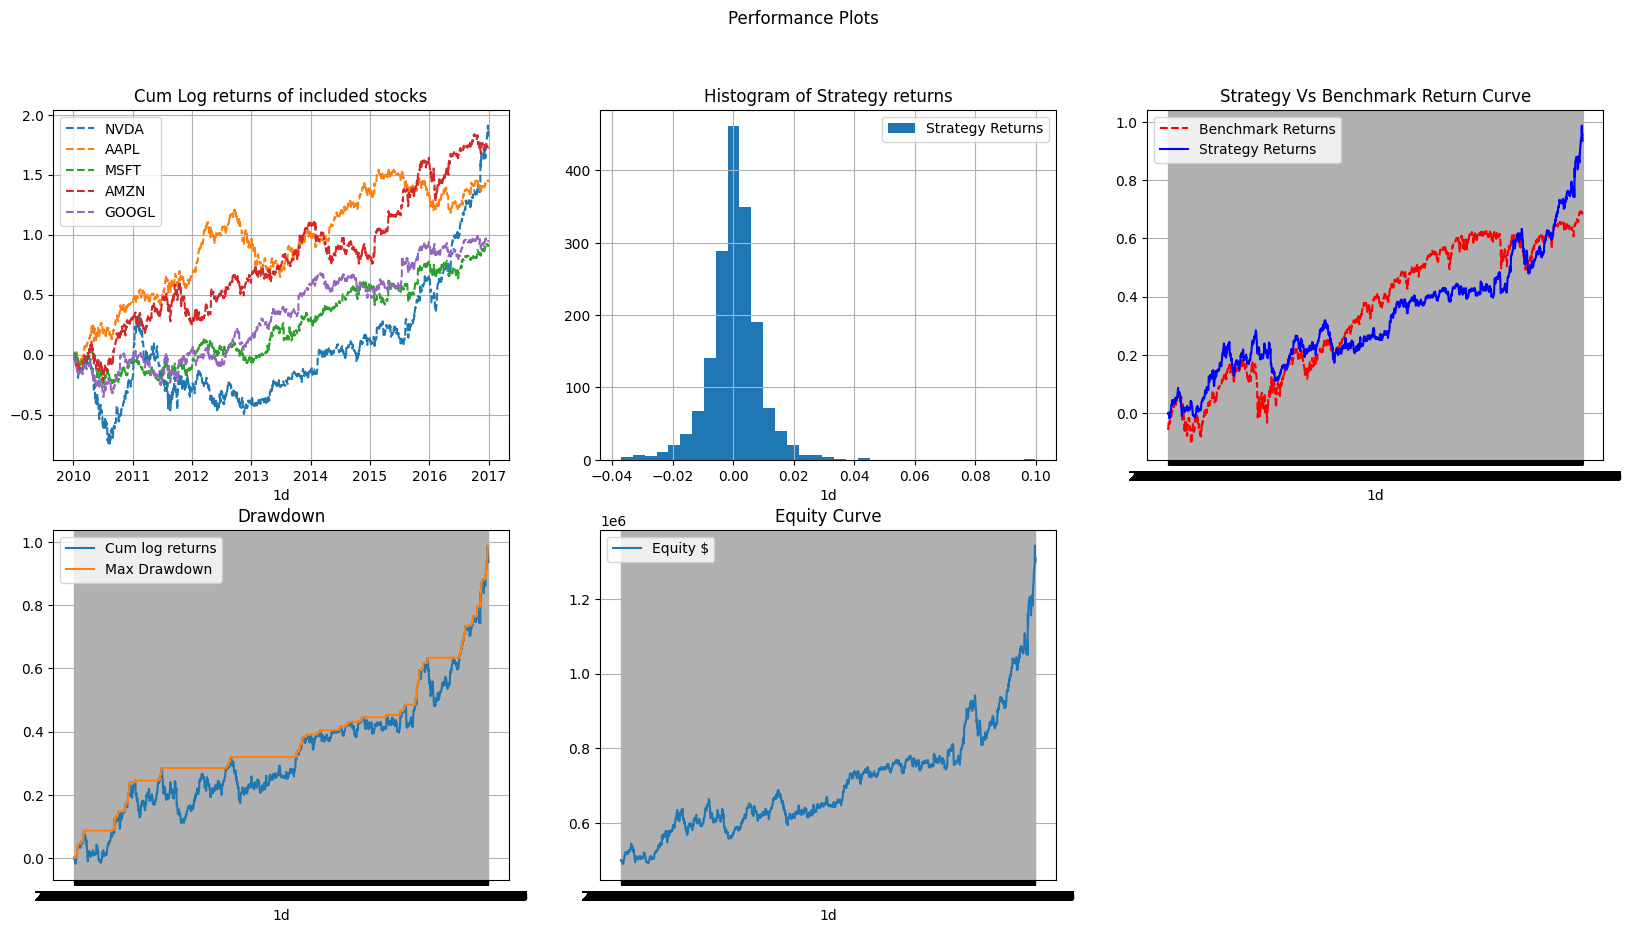

In [ ]:
if __name__ == "__main__":
    # Running on train set, with default parameters for indicators
    stocks = stock_symbols
    A = RSI_MACD_EMA_Strategy(symbol=stocks, start=training_start, end= training_end, backtrack=200, interval="1d", capital=initial_capital, transaction_cost=transaction_cost, verbose=True)
    A.run_strategy(macd_fast=12, macd_slow=26, macd_signal=9, ema_window=200, rsi_window=14)
    performance_results = A.performance()
    A.performance_plots()

Grid Search to optimise parameters

In [ ]:
def optimise_parameters(symbols, start, end, initial_capital, transaction_cost, macd_fast_range, macd_slow_range, macd_signal_range, ema_window_range):
    best_sharpe = -np.inf
    best_macd_fast, best_macd_slow, best_macd_signal = None, None, None
    best_ema_window = None

    # Using GridSearch, test over all combinations of indicator parameters
    for ema_window in ema_window_range:
        for macd_fast in macd_fast_range:
            for macd_slow in macd_slow_range:
                # Requirement here is that MACD fast value has to be smaller than MACD slow
                if macd_fast >= macd_slow:
                    continue
                for macd_signal in macd_signal_range:
                    # Initialize and run the strategy
                    # Backtrack value is the ema_window size, as ema_window size is the largest parameter value, and we need the raw data from then onwards
                    strategy = RSI_MACD_EMA_Strategy(symbol=symbols, start=start, end=end, backtrack=ema_window, interval="1d", capital=initial_capital, transaction_cost=transaction_cost, verbose=False)
                    strategy.run_strategy(macd_fast, macd_slow, macd_signal, ema_window, rsi_window=14)
                    performance_results = strategy.performance()
                    sharpe_ratio = performance_results[2]

                    # Update best parameters if current Sharpe Ratio is higher
                    if sharpe_ratio > best_sharpe:
                        best_sharpe = sharpe_ratio
                        best_macd_fast = macd_fast
                        best_macd_slow = macd_slow
                        best_macd_signal = macd_signal
                        best_ema_window = ema_window

    print(f"Best Parameters - MACD Fast EMA: {best_macd_fast}, MACD Slow EMA: {best_macd_slow}, MACD Signal: {best_macd_signal}, "
          f"EMA Window: {best_ema_window} with Sharpe Ratio: {best_sharpe}")

    return (best_macd_fast, best_macd_slow, best_macd_signal, best_ema_window)

In [ ]:
if __name__ == "__main__":
    # Set parameters for training data optimisation
    stocks = stock_symbols
    training_start = "2010-01-01"
    training_end = "2016-12-31"
    initial_capital = 500000
    transaction_cost = 0

    # Define parameter ranges
    # RSI parameters are fixed, as we are utilising the conventional 14-day RSI period for 30 and 70 overbought/oversold conditions
    macd_fast_range = [7, 9, 12, 15]  # Modify as needed
    macd_slow_range = [14, 26, 35, 40]  # Modify as needed
    macd_signal_range = [5, 9, 11, 15]  # Modify as needed
    ema_window_range = [50, 100, 200] # Modify as needed

    # Optimise parameters on training data
    best_macd_fast, best_macd_slow, best_macd_signal, best_ema_window = optimise_parameters(symbols=stocks, start=training_start, end=training_end, initial_capital=initial_capital, transaction_cost=transaction_cost,
    macd_fast_range=macd_fast_range, macd_slow_range=macd_slow_range, macd_signal_range=macd_signal_range, ema_window_range=ema_window_range)


<ipython-input-3-0ebe6ab79264>:100: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.stored_data = pd.concat([self.stored_data, trade_detail])


Performance Metrics
The total capital at end of strategy: 729017.9
The annual regular returns: 5.55 %
The annual benchmark regular returns: 10.27 %
The annual regular std deviation: 14.86 %
The annual Sharpe Ratio: 0.37
The returns on investment from 2010-01-01 to 2016-12-31 by this strategy is 45.8 %
The annual Sortino Ratio: 0.53
The total trades taken by the strategy: 1010


<ipython-input-3-0ebe6ab79264>:100: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.stored_data = pd.concat([self.stored_data, trade_detail])


Performance Metrics
The total capital at end of strategy: 681242.2
The annual regular returns: 4.53 %
The annual benchmark regular returns: 10.27 %
The annual regular std deviation: 14.97 %
The annual Sharpe Ratio: 0.30
The returns on investment from 2010-01-01 to 2016-12-31 by this strategy is 36.2 %
The annual Sortino Ratio: 0.42
The total trades taken by the strategy: 960


<ipython-input-3-0ebe6ab79264>:100: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.stored_data = pd.concat([self.stored_data, trade_detail])


...

Performance Metrics
The total capital at end of strategy: 1122151.0
The annual regular returns: 12.32 %
The annual benchmark regular returns: 10.31 %
The annual regular std deviation: 13.02 %
The annual Sharpe Ratio: 0.95
The returns on investment from 2010-01-01 to 2016-12-31 by this strategy is 124.4 %
The annual Sortino Ratio: 1.35
The total trades taken by the strategy: 314


<ipython-input-3-0ebe6ab79264>:100: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.stored_data = pd.concat([self.stored_data, trade_detail])


Performance Metrics
The total capital at end of strategy: 1081683.2
The annual regular returns: 11.72 %
The annual benchmark regular returns: 10.31 %
The annual regular std deviation: 13.13 %
The annual Sharpe Ratio: 0.89
The returns on investment from 2010-01-01 to 2016-12-31 by this strategy is 116.3 %
The annual Sortino Ratio: 1.27
The total trades taken by the strategy: 298


<ipython-input-3-0ebe6ab79264>:100: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.stored_data = pd.concat([self.stored_data, trade_detail])


Performance Metrics
The total capital at end of strategy: 1037077.0
The annual regular returns: 11.05 %
The annual benchmark regular returns: 10.31 %
The annual regular std deviation: 13.13 %
The annual Sharpe Ratio: 0.84
The returns on investment from 2010-01-01 to 2016-12-31 by this strategy is 107.4 %
The annual Sortino Ratio: 1.20
The total trades taken by the strategy: 294
Best Parameters - MACD Fast EMA: 7, MACD Slow EMA: 14, MACD Signal: 15, EMA Window: 200 with Sharpe Ratio: 1.1209152237661912


<ipython-input-3-0ebe6ab79264>:100: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.stored_data = pd.concat([self.stored_data, trade_detail])


Performance Metrics
The total capital at end of strategy: 1351009.7
The annual regular returns: 15.46 %
The annual benchmark regular returns: 11.12 %
The annual regular std deviation: 13.79 %
The annual Sharpe Ratio: 1.12
The returns on investment from 2010-01-01 to 2016-12-31 by this strategy is 170.2 %
The annual Sortino Ratio: 1.60
The total trades taken by the strategy: 354


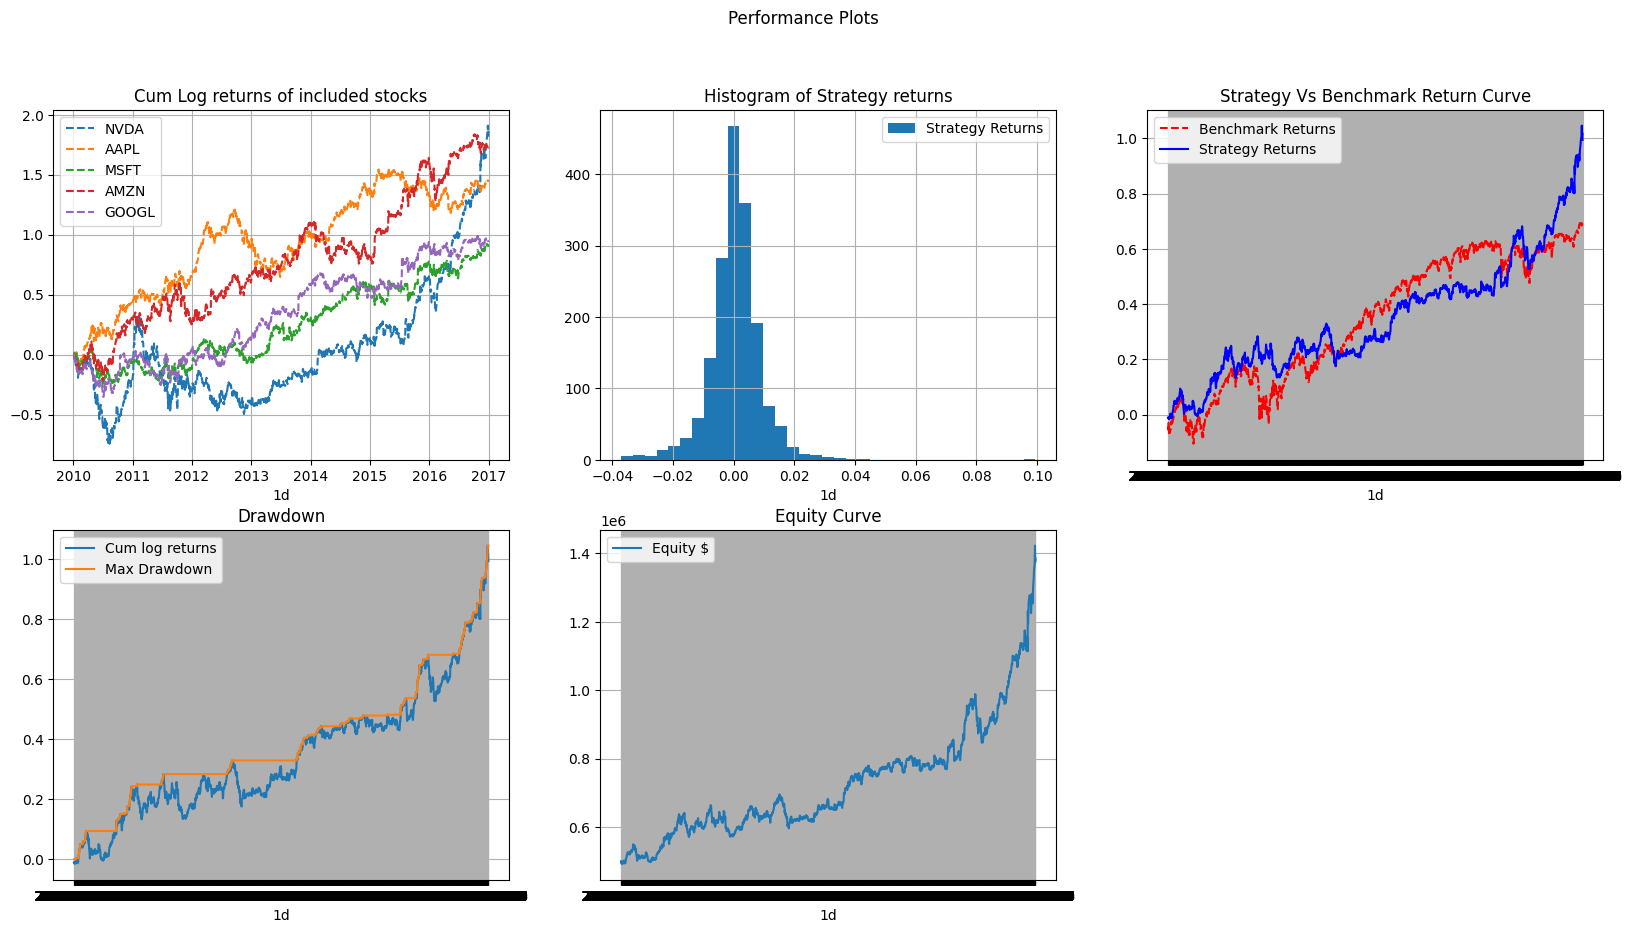

In [ ]:
# Compare difference in training period using optimised parameters
training_start = "2010-01-01"
training_end = "2016-12-31"
A = RSI_MACD_EMA_Strategy(symbol=stock_symbols, start=training_start, end=training_end, backtrack=best_ema_window, interval="1d", capital=initial_capital, transaction_cost=transaction_cost, verbose=False)
A.run_strategy(macd_fast=best_macd_fast, macd_slow=best_macd_slow, macd_signal=best_macd_signal, ema_window=best_ema_window, rsi_window=14)
A.performance()
A.performance_plots()

<ipython-input-3-0ebe6ab79264>:100: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.stored_data = pd.concat([self.stored_data, trade_detail])


Performance Metrics
The total capital at end of strategy: 913328.7
The annual regular returns: 22.57 %
The annual benchmark regular returns: 12.79 %
The annual regular std deviation: 14.24 %
The annual Sharpe Ratio: 1.58
The returns on investment from 2017-01-01 to 2019-12-31 by this strategy is 82.7 %
The annual Sortino Ratio: 1.97
The total trades taken by the strategy: 110


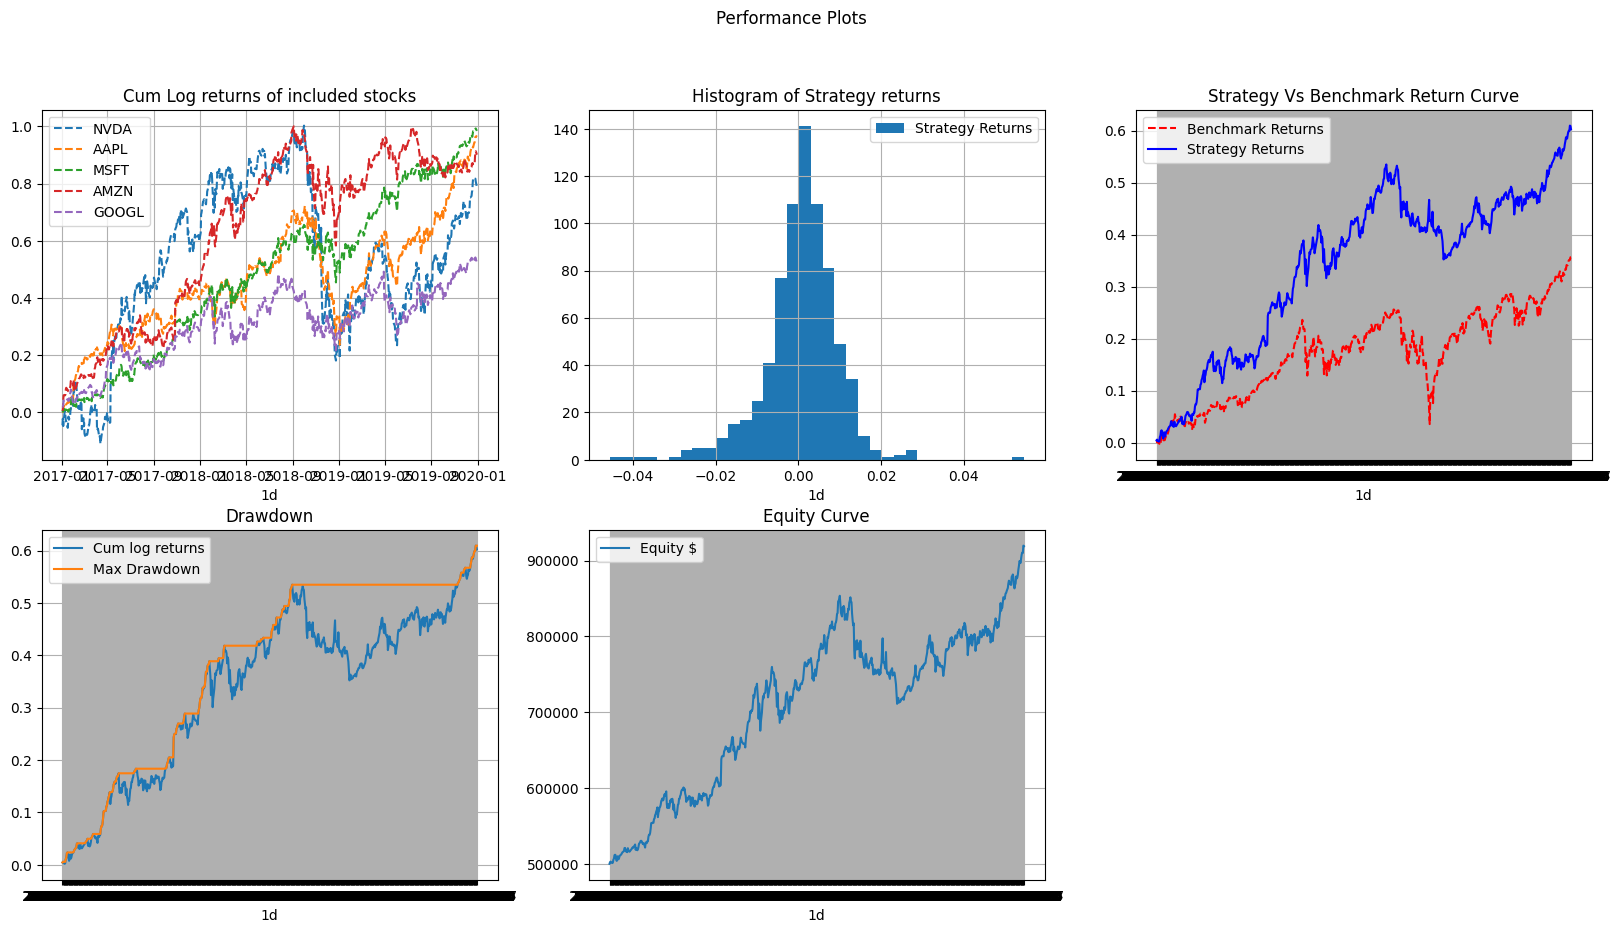

In [ ]:
# Test on new data (2017-2019) using optimised parameters
test_start = "2017-01-01"
test_end = "2019-12-31"
A = RSI_MACD_EMA_Strategy(symbol=stock_symbols, start=test_start, end=test_end, backtrack=best_ema_window, interval="1d", capital=initial_capital, transaction_cost=transaction_cost, verbose=False)
A.run_strategy(macd_fast=best_macd_fast, macd_slow=best_macd_slow, macd_signal=best_macd_signal, ema_window=best_ema_window, rsi_window=14)
A.performance()
A.performance_plots()